# Solitary waves of the Whitham equation, complex-step Newton against Newton with a dense Jacobian

The Whitham equation

$$u_t + \mathcal{L} u_x + \tfrac{3}{2}\, u\, u_x = 0, \qquad \widehat{\mathcal{L} u}(\xi) = m(\xi)\, \hat u(\xi), \qquad m(\xi) = \sqrt{\frac{\tanh \xi}{\xi}},$$

replaces the dispersion of the KdV equation by the exact linear dispersion relation of water waves (G. B. Whitham, *Linear and Nonlinear Waves*, Wiley, 1974). The operator $\mathcal{L}$ is a Fourier multiplier, a nonlocal operator. For $|\xi|$ small $m(\xi) \approx 1 - \xi^2/6$, and the equation reduces to KdV.

A solitary wave travelling with speed $c$ is a solution $u(x - ct)$. Inserting it and integrating once, with $u \to 0$ at infinity, gives

$$-c\, u + \mathcal{L} u + \tfrac{3}{4}\, u^2 = 0.$$

We compute such waves on a long periodic interval with periodic cubic splines, by Newton's method. The point of this notebook is the Jacobian. Since $\mathcal{L}$ is nonlocal, the Galerkin matrix of $\mathcal{L}$ is **dense**, so Newton's method with the assembled Jacobian costs $O(n^2)$ in memory and $O(n^3)$ in time per iteration. The matrix of $\mathcal{L}$ is circulant, though, so its product with a vector costs $O(n \log n)$ by the FFT. The complex-step Newton-Krylov method `fd.csnewton` needs only products $J v$, which it takes from the residual itself,

$$J(u)\, v = \frac{\operatorname{Im} F(u + i h v)}{h}, \qquad h = 10^{-20},$$

exact to rounding, with no Jacobian to derive, assemble or store. Here it is more than 50 times faster than the direct Newton method at $n = 4096$, and it runs at sizes where the dense Jacobian does not fit in memory.

In [1]:
import time
import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt
import femd as fd
from femd import dx

**The Galerkin matrix of a Fourier multiplier.** Let $V$ be the space of periodic splines of degree $p$ on a uniform grid of $n$ elements of width $h$ on an interval of length $L$, with basis $N_0, \dots, N_{n-1}$, the translates of one B-spline. For a multiplier $\mathcal{L}$ with an even real symbol $m$, the matrix $A_{ij} = \left(\mathcal{L} N_j, N_i\right)$ depends only on $j - i$, so it is circulant. Expanding the B-spline in its Fourier series, whose coefficients are those of $\mathrm{sinc}^{p+1}$, gives its eigenvalues

$$\lambda_k = h \sum_{l = -\infty}^{\infty} m\left(\frac{2\pi (k + l n)}{L}\right) \mathrm{sinc}^{2p+2}\left(\frac{k + l n}{n}\right), \qquad k = 0, \dots, n - 1,$$

with $\mathrm{sinc}\, x = \sin(\pi x)/(\pi x)$. The terms decay like $|l|^{-2p-2}$, and we keep $|l| \le 200$. Then $A c = \mathcal{F}^{-1}\left(\lambda\, \mathcal{F} c\right)$ costs two FFTs.

We check the formula against FEMd. The symbol $m = 1$ must give the mass matrix $(u, v)$, and $m = \xi^2$ the stiffness matrix $(u', v')$.

In [2]:
def multiplier_eigenvalues(symbol, n, L, p, lmax=200):
    # eigenvalues of the Galerkin matrix of the multiplier `symbol` on periodic splines
    h = L / n
    k = np.fft.fftfreq(n, 1.0 / n)                  # 0, 1, ..., n/2 - 1, -n/2, ..., -1
    lam = np.zeros(n)
    for l in range(-lmax, lmax + 1):
        j = k + l * n
        lam += symbol(2 * np.pi * j / L) * np.sinc(j / n) ** (2 * p + 2)
    return h * lam

def circulant_apply(lam, c):
    # A c for the circulant matrix with eigenvalues lam, c real
    n = len(lam)
    return np.fft.irfft(lam[: n // 2 + 1] * np.fft.rfft(c), n)

L, p, n = 80.0, 3, 64
V = fd.SplineSpace(np.linspace(-L / 2, L / 2, n + 1), p, bc="periodic")
u, v = fd.TrialFunction(V), fd.TestFunction(V)
M = fd.form(u * v * dx).assemble()
K = fd.form(fd.D(u) * fd.D(v) * dx).assemble()

c = np.random.default_rng(0).standard_normal(n)
lm = multiplier_eigenvalues(lambda xi: np.ones_like(xi), n, L, p)
lk = multiplier_eigenvalues(lambda xi: xi**2, n, L, p, lmax=2000)
print("mass:      ", np.max(np.abs(circulant_apply(lm, c) - M.tocsr() @ c)))
print("stiffness: ", np.max(np.abs(circulant_apply(lk, c) - K.tocsr() @ c)))

mass:       6.661338147750939e-16
stiffness:  2.220446049250313e-15


**The residual.** The Galerkin equations are

$$F(c) = (A_{\mathcal{L}} - c_s M)\, c + \tfrac{3}{4}\left(u_h^2, N_i\right) = 0,$$

where $c$ is the coefficient vector of $u_h$ and $c_s$ the speed. The linear part $A_{\mathcal{L}} - c_s M$ is circulant, with eigenvalues $\lambda_k^{\mathcal{L}} - c_s \lambda_k^{M}$, and is applied by the FFT. The quadratic term is a FEMd form, assembled at the current coefficients with `N.assemble(w=c)`.

**A pitfall of the complex step.** `fd.csnewton` evaluates $F$ at $c + i h v$ with $h = 10^{-20}$, so the imaginary part is about $10^{-20}$ times the real part. A complex FFT of that vector mixes the two parts, and its rounding errors in the real part, of size $10^{-17}$, land in the imaginary part and are divided by $h$. A real linear operator must therefore be applied to the real and the imaginary parts **separately**, as below. FEMd's own forms and matrices already do this.

In [3]:
def symbol(xi):
    # sqrt(tanh(xi)/xi), equal to 1 at xi = 0
    a = np.abs(xi)
    return np.sqrt(np.tanh(a) / np.where(a > 0, a, 1.0)) * (a > 0) + (a == 0)

def whitham(n, L=80.0, p=3, speed=1.1):
    V = fd.SplineSpace(np.linspace(-L / 2, L / 2, n + 1), p, bc="periodic")
    v = fd.TestFunction(V)
    w = fd.Function(V, "w")
    N = fd.form(0.75 * w * w * v * dx)                      # (3/4)(w^2, v)
    lam = multiplier_eigenvalues(symbol, n, L, p) - speed * multiplier_eigenvalues(np.ones_like, n, L, p)

    def linear(c):                                          # (A_L - c_s M) c, real and imaginary parts apart
        if np.iscomplexobj(c):
            return circulant_apply(lam, c.real) + 1j * circulant_apply(lam, c.imag)
        return circulant_apply(lam, c)

    def F(c):
        return linear(c) + np.asarray(N.assemble(w=c))

    def precond(r):                                         # (A_L - c_s M)^{-1} r by the FFT
        return np.fft.irfft(np.fft.rfft(r) / lam[: n // 2 + 1], n)

    # initial guess: the KdV solitary wave, from m(xi) ~ 1 - xi^2/6
    kappa, A = np.sqrt(1.5 * (speed - 1)), 2 * (speed - 1)
    u0 = fd.Function(V, "u0").interpolate(lambda x: A / np.cosh(kappa * x) ** 2)
    return dict(V=V, w=w, N=N, lam=lam, F=F, precond=precond, c0=np.asarray(u0.vector).copy())

**Complex-step Newton-Krylov.** Speed $c_s = 1.1$ and $n = 1024$ cubic elements on $(-40, 40)$. Each Newton step solves $J s = F$ by GMRES with the products $Jv$ from the complex step, preconditioned by the linear part $A_{\mathcal{L}} - c_s M$, which the FFT inverts exactly. The preconditioned Jacobian is the identity plus the term coming from $\tfrac{3}{2} u\, v$, so GMRES needs about a dozen iterations per Newton step, whatever $n$ is.

In [4]:
P = whitham(1024)
t0 = time.perf_counter()
c_cs, info = fd.csnewton(P["F"], P["c0"], M=P["precond"], tol=1e-11)
t_cs = time.perf_counter() - t0
print(info)
print(f"time {t_cs:.3f} s,  ||F|| = {np.linalg.norm(P['F'](c_cs)):.1e}")

CSNewtonInfo(converged=True, newton_iterations=4, krylov_iterations=44, residual=5.606666232888662e-16)
time 0.009 s,  ||F|| = 5.6e-16


**Newton's method with the exact dense Jacobian.** The Jacobian is $J = A_{\mathcal{L}} - c_s M + \tfrac{3}{2}\left(u_h N_j, N_i\right)$. The last matrix is banded and comes from FEMd's symbolic Jacobian of the form, `N.jacobian(w, w=c)`. The first is dense, built once from its first column. `fd.newton_system` then factors the dense $J$ by LU at every iteration.

In [5]:
n = 1024
Ad = sla.circulant(np.fft.irfft(P["lam"][: n // 2 + 1], n))     # the dense matrix A_L - c_s M

def jacobian(c):
    return Ad + P["N"].jacobian(P["w"], w=c).tocsr().toarray()

t0 = time.perf_counter()
c_dn, info_dn = fd.newton_system(P["F"], jacobian, P["c0"], tol=1e-11)
t_dn = time.perf_counter() - t0
print("||F||:", "  ".join(f"{r:.1e}" for r in info_dn.residuals))
print(f"{info_dn.iterations} iterations, time {t_dn:.3f} s")
print("difference between the two solutions:", np.max(np.abs(c_cs - c_dn)))

||F||: 8.5e-04  2.1e-04  6.0e-06  2.8e-09  5.5e-16
4 iterations, time 0.083 s
difference between the two solutions: 1.1619233353243885e-11


Both methods take four Newton steps and converge quadratically to the same solution. The complex-step products are the exact Jacobian applied to $v$. We compare them with the dense Jacobian, together with a one-sided difference $\left(F(c + \varepsilon v) - F(c)\right)/\varepsilon$ and with the complex step done wrongly, through a complex FFT.

In [6]:
c, vv = c_dn, np.random.default_rng(1).standard_normal(n)
exact = jacobian(c) @ vv
h = 1e-20
cs = P["F"](c + 1j * h * vv).imag / h
eps = np.sqrt(np.finfo(float).eps) * (1 + np.linalg.norm(c)) / np.linalg.norm(vv)
fdiff = (P["F"](c + eps * vv) - P["F"](c)) / eps
lam = P["lam"]
naive = (np.fft.ifft(lam * np.fft.fft(c + 1j * h * vv)) + np.asarray(P["N"].assemble(w=c + 1j * h * vv))).imag / h
for name, Jv in [("complex step", cs), ("finite difference", fdiff), ("complex step through a complex FFT", naive)]:
    print(f"{name:36s} relative error {np.linalg.norm(Jv - exact) / np.linalg.norm(exact):.1e}")

complex step                         relative error 4.6e-16
finite difference                    relative error 9.8e-09
complex step through a complex FFT   relative error 5.3e+02


**The solitary wave.** The Whitham wave of speed $1.1$ is a little higher and narrower than the KdV wave of the same speed, which was the initial guess.

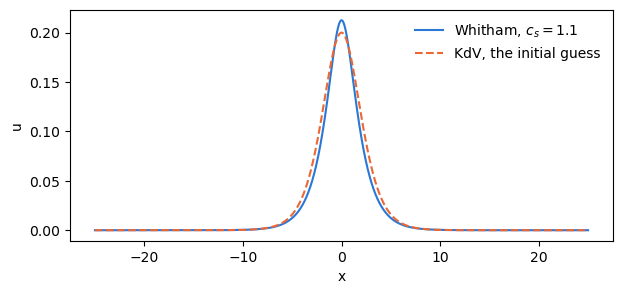

amplitude 0.2125323923


In [ ]:
uh = fd.Function(P["V"], "u", c_cs)
xs = np.linspace(-25, 25, 1001)
kappa, A = np.sqrt(1.5 * 0.1), 2 * 0.1
plt.figure(figsize=(7, 3))
plt.plot(xs, uh(xs), color="#2a78d6", label="Whitham, $c_s = 1.1$")
plt.plot(xs, A / np.cosh(kappa * xs) ** 2, "--", color="#eb6834", label="KdV, the initial guess")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(frameon=False)
plt.show()
print(f"amplitude {uh(np.array([0.0]))[0]:.10f}")

**Cost against $n$.** The dense Newton method stops at $n = 4096$, where its Jacobian already takes 134 MB. At $n = 131\,072$ it would take 137 GB. The complex-step method keeps going, and the amplitude converges at the rate $h^4$ of cubic splines.

In [8]:
rows = []
for n in [256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]:
    P = whitham(n)
    t0 = time.perf_counter()
    c_cs, info = fd.csnewton(P["F"], P["c0"], M=P["precond"], tol=1e-11)
    t_cs = time.perf_counter() - t0
    amp = fd.Function(P["V"], "u", c_cs)(np.array([0.0]))[0]
    t_dn = np.nan
    if n <= 4096:
        Ad = sla.circulant(np.fft.irfft(P["lam"][: n // 2 + 1], n))
        jac = lambda c: Ad + P["N"].jacobian(P["w"], w=c).tocsr().toarray()
        t0 = time.perf_counter()
        fd.newton_system(P["F"], jac, P["c0"], tol=1e-11)
        t_dn = time.perf_counter() - t0
    rows.append((n, info.newton_iterations, info.krylov_iterations, t_cs, t_dn, amp))

print(f"{'n':>7} {'Newton':>7} {'GMRES':>6} {'csnewton (s)':>13} {'dense Newton (s)':>17} {'amplitude':>15} {'change':>9}")
for i, (n, it, git, tc, td, amp) in enumerate(rows):
    change = f"{abs(amp - rows[i - 1][5]):9.1e}" if i else ""
    dense = f"{td:17.3f}" if np.isfinite(td) else f"{'-':>17}"
    print(f"{n:7d} {it:7d} {git:6d} {tc:13.3f} {dense} {amp:15.12f} {change}")

      n  Newton  GMRES  csnewton (s)  dense Newton (s)       amplitude    change
    256       4     42         0.004             0.003  0.212539717395 
    512       4     43         0.006             0.015  0.212532753115   7.0e-06
   1024       4     44         0.011             0.076  0.212532392264   3.6e-07
   2048       4     46         0.022             0.588  0.212532370764   2.1e-08
   4096       4     46         0.042             4.115  0.212532369436   1.3e-09
   8192       4     48         0.075                 -  0.212532369354   8.3e-11
  16384       4     50         0.186                 -  0.212532369348   5.2e-12
  32768       4     50         0.319                 -  0.212532369348   3.2e-13
  65536       4     52         0.669                 -  0.212532369348   2.0e-14
 131072       4     54         1.338                 -  0.212532369348   1.3e-15


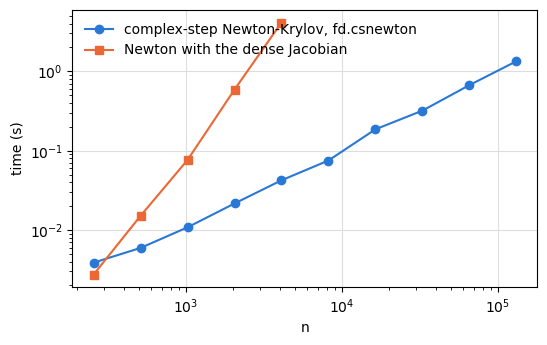

In [9]:
ns = np.array([r[0] for r in rows]); tc = np.array([r[3] for r in rows]); td = np.array([r[4] for r in rows])
plt.figure(figsize=(6, 3.6))
plt.loglog(ns, tc, "o-", color="#2a78d6", label="complex-step Newton-Krylov, fd.csnewton")
ok = np.isfinite(td)
plt.loglog(ns[ok], td[ok], "s-", color="#eb6834", label="Newton with the dense Jacobian")
plt.xlabel("n"); plt.ylabel("time (s)"); plt.legend(frameon=False, loc="upper left")
plt.grid(True, which="major", color="#ddd")
plt.show()

**Why the complex step wins here, and when it does not.**

- The Jacobian is dense, because $\mathcal{L}$ is nonlocal, while its product with a vector is cheap. Newton's method with an assembled Jacobian pays $O(n^3)$ per step, and `fd.csnewton` pays a few FFTs and assemblies per GMRES iteration, with a number of GMRES iterations that hardly grows with $n$.
- The products $Jv$ are exact to rounding, so Newton converges quadratically down to round-off, like the direct method. A one-sided difference loses half the digits in every product.
- Nothing has to be derived. The Jacobian of the nonlocal term is never written down, and the same code works for any symbol $m$ and any nonlinearity written with NumPy and FEMd forms.

For a residual that is a local form, as in `example2`, `fd.newton` with the symbolic Jacobian and a banded solve remains the method of choice. A matrix-free Jacobian action written by hand would do as well as the complex step here. The complex step gives that action for free from $F$.